In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

In [7]:
import os
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

df.to_csv('data/heart.csv', index=False)
print("Dataset downloaded successfully")
print(f"Shape: {df.shape}")
df.head()

Dataset downloaded successfully
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (303, 13)
y shape: (303,)

Target distribution:
target
1    165
0    138
Name: count, dtype: int64


In [9]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nData types:\n")
print(df.dtypes)

print("\nDuplicates:", df.duplicated().sum())

Missing values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Duplicates: 1


In [10]:
# Remove duplicates
df = df.drop_duplicates()

print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (302, 14)


In [11]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (302, 13)
y shape: (302,)

Target distribution:
target
1    164
0    138
Name: count, dtype: int64


**define feature types**

In [12]:
# Define feature groups
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical_features = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


**preprocessing pipelines**

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

**build baseline model**

In [14]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

**train model**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (241, 13)
Test shape: (61, 13)


In [17]:
baseline_model.fit(X_train, y_train)
print("Baseline model trained successfully.")

Baseline model trained successfully.


**evaluate model**

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8524590163934426
Precision: 0.8529411764705882
Recall: 0.8787878787878788
F1 Score: 0.8656716417910447
ROC-AUC: 0.8971861471861471


**define multiple models**

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

**training & evaluation loop**

In [20]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(result)

In [21]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,SVM,0.819672,0.789474,0.909091,0.845070,0.901515
0,Logistic Regression,0.852459,0.852941,0.878788,0.865672,0.897186
1,Random Forest,0.786885,0.763158,0.878788,0.816901,0.896645
3,KNN,0.754098,0.750000,0.818182,0.782609,0.858225


In [22]:
import joblib

# Save the best model (Logistic Regression pipeline)
joblib.dump(baseline_model, "final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [23]:
# Get feature names after preprocessing
feature_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = baseline_model.named_steps["classifier"].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df = importance_df.sort_values(by="Coefficient", ascending=False)

importance_df.head(10)

,Feature,Coefficient
21,cat__ca_0,0.987143
28,cat__thal_2,0.828484
10,cat__cp_3,0.677018
9,cat__cp_2,0.649390
5,cat__sex_0,0.612386
25,cat__ca_4,0.500382
16,cat__exang_0,0.390634
20,cat__slope_2,0.359965
3,num__thalach,0.335050
14,cat__restecg_1,0.293668


**Cross-validation on the baseline model**

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std CV ROC-AUC:", cv_scores.std())

Cross-validation ROC-AUC scores: [0.85185185 0.93006993 0.88811189 0.91958042 0.95104895]
Mean CV ROC-AUC: 0.9081326081326081
Std CV ROC-AUC: 0.034705802764729204


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__penalty": ["l2"]
}

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.9186609686609687


In [26]:
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

In [27]:
print("Final Model Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))

Final Model Metrics
Accuracy: 0.8524590163934426
Precision: 0.8333333333333334
Recall: 0.9090909090909091
F1 Score: 0.8695652173913043
ROC-AUC: 0.8939393939393939


In [28]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [29]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_final))


Confusion Matrix:

[[22  6]
 [ 3 30]]


In [30]:
import joblib
joblib.dump(final_model, "final_model.pkl")
print("Final tuned model saved as final_model.pkl")

Final tuned model saved as final_model.pkl


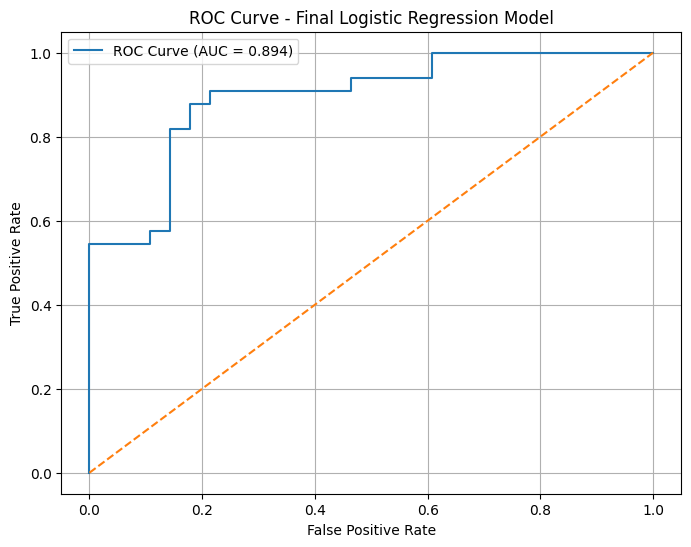

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
auc_score = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()

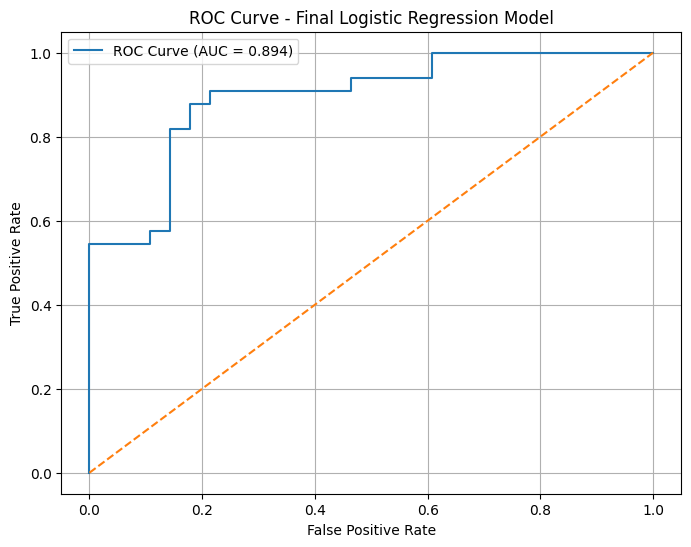

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_final_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

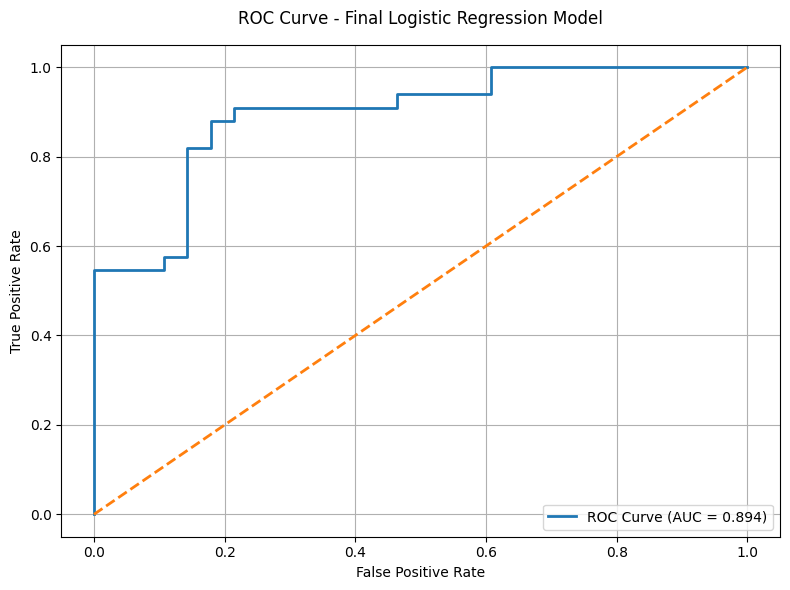

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression Model", pad=15)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_final_logistic_regression_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
final_results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_prob_final)
    ]
})

final_results_df["Value"] = final_results_df["Value"].round(3)
final_results_df

,Metric,Value
0,Accuracy,0.852
1,Precision,0.833
2,Recall,0.909
3,F1 Score,0.870
4,ROC-AUC,0.894


In [35]:
final_results_df.to_csv("final_results_summary.csv", index=False)
print("Saved as final_results_summary.csv")

Saved as final_results_summary.csv


In [36]:
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df.to_csv("model_comparison_results.csv", index=False)
print("Saved as model_comparison_results.csv")
results_df

Saved as model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.819672,0.789474,0.909091,0.845070,0.901515
1,Logistic Regression,0.852459,0.852941,0.878788,0.865672,0.897186
2,Random Forest,0.786885,0.763158,0.878788,0.816901,0.896645
3,KNN,0.754098,0.750000,0.818182,0.782609,0.858225


In [37]:
importance_df.to_csv("feature_importance_logistic_regression.csv", index=False)
print("Saved as feature_importance_logistic_regression.csv")
importance_df.head(10)

Saved as feature_importance_logistic_regression.csv


,Feature,Coefficient
21,cat__ca_0,0.987143
28,cat__thal_2,0.828484
10,cat__cp_3,0.677018
9,cat__cp_2,0.649390
5,cat__sex_0,0.612386
25,cat__ca_4,0.500382
16,cat__exang_0,0.390634
20,cat__slope_2,0.359965
3,num__thalach,0.335050
14,cat__restecg_1,0.293668


In [38]:
final_feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
final_coefficients = final_model.named_steps["classifier"].coef_[0]

final_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient": final_coefficients
}).sort_values(by="Coefficient", ascending=False)

final_importance_df.to_csv("feature_importance_logistic_regression.csv", index=False)

print("Updated feature importance saved from final_model.")
final_importance_df.head(10)

Updated feature importance saved from final_model.


,Feature,Coefficient
28,cat__thal_2,0.582755
21,cat__ca_0,0.548745
9,cat__cp_2,0.379013
5,cat__sex_0,0.319284
16,cat__exang_0,0.310130
3,num__thalach,0.298509
20,cat__slope_2,0.218411
10,cat__cp_3,0.204505
14,cat__restecg_1,0.164887
8,cat__cp_1,0.096729


In [39]:
import os
import shutil

# Create folders
os.makedirs("models", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("reports/model_results", exist_ok=True)

# Move saved files into the right places
if os.path.exists("final_model.pkl"):
    shutil.move("final_model.pkl", "models/final_model.pkl")

if os.path.exists("roc_curve_final_logistic_regression_clean.png"):
    shutil.move(
        "roc_curve_final_logistic_regression_clean.png",
        "reports/figures/roc_curve_final_logistic_regression.png"
    )

if os.path.exists("final_results_summary.csv"):
    shutil.move(
        "final_results_summary.csv",
        "reports/model_results/final_results_summary.csv"
    )

if os.path.exists("model_comparison_results.csv"):
    shutil.move(
        "model_comparison_results.csv",
        "reports/model_results/model_comparison_results.csv"
    )

if os.path.exists("feature_importance_logistic_regression.csv"):
    shutil.move(
        "feature_importance_logistic_regression.csv",
        "reports/model_results/feature_importance_logistic_regression.csv"
    )

print("Project outputs organised successfully.")

Project outputs organised successfully.


In [40]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Raw dataset from source
raw_df = pd.read_csv(url)
raw_df.to_csv("data/raw/heart.csv", index=False)

# Cleaned dataset used for modeling
df.to_csv("data/processed/heart_clean.csv", index=False)

print("Saved raw dataset to data/raw/heart.csv")
print("Saved cleaned dataset to data/processed/heart_clean.csv")

Saved raw dataset to data/raw/heart.csv
Saved cleaned dataset to data/processed/heart_clean.csv


In [41]:
loaded_model = joblib.load("models/final_model.pkl")

sample_input = X_test.iloc[[0]]
sample_true = y_test.iloc[0]

sample_pred = loaded_model.predict(sample_input)[0]
sample_prob = loaded_model.predict_proba(sample_input)[0][1]

print("True label:", sample_true)
print("Predicted label:", sample_pred)
print("Predicted probability of heart disease:", round(sample_prob, 3))
sample_input

True label: 0
Predicted label: 0
Predicted probability of heart disease: 0.069


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1


In [42]:
import os
from textwrap import dedent

os.makedirs("src", exist_ok=True)

predict_code = dedent("""
import joblib
import pandas as pd

MODEL_PATH = "models/final_model.pkl"

def load_model(model_path=MODEL_PATH):
    return joblib.load(model_path)

def predict_heart_disease(input_data, model_path=MODEL_PATH):
    model = load_model(model_path)

    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()
    else:
        raise ValueError("input_data must be a dictionary or a pandas DataFrame")

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return {
        "prediction": int(prediction),
        "probability_of_heart_disease": float(probability)
    }

if __name__ == "__main__":
    sample_patient = {
        "age": 57,
        "sex": 1,
        "cp": 0,
        "trestbps": 150,
        "chol": 276,
        "fbs": 0,
        "restecg": 0,
        "thalach": 112,
        "exang": 1,
        "oldpeak": 0.6,
        "slope": 1,
        "ca": 1,
        "thal": 1
    }

    result = predict_heart_disease(sample_patient)
    print(result)
""")

with open("src/predict.py", "w") as f:
    f.write(predict_code)

print("Created src/predict.py")

Created src/predict.py


In [43]:
!python src/predict.py

{'prediction': 0, 'probability_of_heart_disease': 0.0687652587394924}


In [44]:
from textwrap import dedent

train_code = dedent("""
import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

DATA_PATH = "data/processed/heart_clean.csv"
MODEL_PATH = "models/final_model.pkl"

def load_data(path=DATA_PATH):
    return pd.read_csv(path)

def build_preprocessor():
    numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor

def train_model():
    df = load_data()

    X = df.drop("target", axis=1)
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocessor = build_preprocessor()

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    param_grid = {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"],
        "classifier__penalty": ["l2"]
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    final_model = grid_search.best_estimator_

    y_pred = final_model.predict(X_test)
    y_prob = final_model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    os.makedirs("models", exist_ok=True)
    joblib.dump(final_model, MODEL_PATH)

    return grid_search.best_params_, metrics

if __name__ == "__main__":
    best_params, metrics = train_model()

    print("Best parameters:", best_params)
    print("Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print(f"Model saved to {MODEL_PATH}")
""")

with open("src/train.py", "w") as f:
    f.write(train_code)

print("Created src/train.py")

Created src/train.py
